# 03 — Dataset Cleaning and Pre-Modelling Setup

This notebook continues after the EDA notebook and keeps interpretation separate from processing.

It performs:

1. problem-session review;
2. strict exclusion of early-close, partial and timing-incomplete sessions;
3. duplicate, missing and non-finite value checks;
4. construction of the primary binary Up/Down target;
5. neutral-threshold sensitivity analysis;
6. feature-definition and multicollinearity audits;
7. chronological train/validation/test splitting;
8. training-only imputation and outlier clipping;
9. export of clean and model-ready datasets.

The original aligned and EDA datasets are never overwritten.

## 1. Environment and project discovery

The notebook searches the current folder and its parents for `data/market.duckdb`. It expects the derived Parquet files produced by the EDA notebook, with DuckDB-table fallbacks.

In [2]:
from pathlib import Path
import json
import warnings

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


def locate_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "market.duckdb").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find data/market.duckdb. Place this notebook inside the Massive project."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / "data"
DERIVED_ROOT = DATA_ROOT / "derived"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
CLEANING_ROOT = OUTPUT_ROOT / "cleaning"
FIGURE_ROOT = CLEANING_ROOT / "figures"
DB_PATH = DATA_ROOT / "market.duckdb"

DERIVED_ROOT.mkdir(parents=True, exist_ok=True)
CLEANING_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

con = duckdb.connect(str(DB_PATH))


def save_figure(fig, filename: str) -> Path:
    path = FIGURE_ROOT / filename
    fig.tight_layout()
    fig.savefig(path, dpi=220, bbox_inches="tight")
    return path


print("Project root:", PROJECT_ROOT)
print("Cleaning output:", CLEANING_ROOT)

Project root: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation
Cleaning output: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\cleaning


## 2. Load the EDA outputs

In [3]:
ALIGNED_PATH = DERIVED_ROOT / "aligned_underlyings_1min.parquet"
AUDIT_PATH = DERIVED_ROOT / "underlying_session_audit.parquet"
DAILY_PATH = DERIVED_ROOT / "daily_underlying_model_dataset.parquet"


def load_parquet_or_table(path: Path, table_name: str) -> pd.DataFrame:
    if path.exists():
        print("Loading", path)
        return pd.read_parquet(path)

    tables = set(
        con.execute(
            "SELECT table_name FROM information_schema.tables"
        ).df()["table_name"]
    )
    if table_name in tables:
        print("Loading DuckDB table", table_name)
        return con.execute(f"SELECT * FROM {table_name}").df()

    raise FileNotFoundError(f"Missing {path} and DuckDB table {table_name}.")


aligned = load_parquet_or_table(ALIGNED_PATH, "aligned_underlyings_1min")
session_audit = load_parquet_or_table(AUDIT_PATH, "underlying_session_audit")
daily_model = load_parquet_or_table(DAILY_PATH, "daily_underlying_model_dataset")

aligned["timestamp_utc"] = pd.to_datetime(aligned["timestamp_utc"], utc=True)
aligned["timestamp_et"] = pd.to_datetime(aligned["timestamp_et"])
aligned["session_date"] = aligned["session_date"].astype(str)
for column in ["spx_timestamp_utc", "vix_timestamp_utc"]:
    if column in aligned.columns:
        aligned[column] = pd.to_datetime(aligned[column], utc=True)

session_audit["session_date"] = session_audit["session_date"].astype(str)
daily_model["session_date"] = pd.to_datetime(daily_model["session_date"])
if "feature_cutoff_timestamp_utc" in daily_model.columns:
    daily_model["feature_cutoff_timestamp_utc"] = pd.to_datetime(
        daily_model["feature_cutoff_timestamp_utc"], utc=True
    )

print("Aligned rows:", len(aligned))
print("Audit sessions:", len(session_audit))
print("Daily rows:", len(daily_model))

Loading C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data\derived\aligned_underlyings_1min.parquet
Loading C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data\derived\underlying_session_audit.parquet
Loading C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data\derived\daily_underlying_model_dataset.parquet
Aligned rows: 194495
Audit sessions: 501
Daily rows: 496


## 3. Basic integrity cleaning

Duplicate timestamps and duplicate daily dates are removed deterministically. Infinite values are converted to missing values so that they cannot silently enter a model.

In [4]:
integrity_before = pd.DataFrame(
    {
        "check": [
            "Duplicate aligned timestamps",
            "Duplicate daily session dates",
            "Missing target values",
            "Non-finite target values",
        ],
        "value": [
            int(aligned.duplicated(["session_date", "timestamp_utc"]).sum()),
            int(daily_model.duplicated(["session_date"]).sum()),
            int(daily_model["final_hour_return"].isna().sum()),
            int((~np.isfinite(pd.to_numeric(daily_model["final_hour_return"], errors="coerce"))).sum()),
        ],
    }
)
display(integrity_before)

aligned = (
    aligned.drop_duplicates(["session_date", "timestamp_utc"], keep="last")
    .sort_values(["session_date", "timestamp_utc"])
    .reset_index(drop=True)
)
daily_model = (
    daily_model.drop_duplicates(["session_date"], keep="last")
    .sort_values("session_date")
    .reset_index(drop=True)
)

numeric_columns = daily_model.select_dtypes(include=[np.number]).columns
daily_model[numeric_columns] = daily_model[numeric_columns].replace([np.inf, -np.inf], np.nan)

,check,value
0,Duplicate aligned timestamps,0
1,Duplicate daily session dates,0
2,Missing target values,0
3,Non-finite target values,0


## 4. Review and classify problem sessions

A strict full session must contain 390 SPY minute bars, exact SPX observations at 14:59 and 15:59 ET, and no missing SPX or VIX values in the final 120-minute feature window from 13:00 through 14:59 ET.

In [5]:
if "clock_minute" not in aligned.columns:
    aligned["clock_minute"] = aligned["timestamp_et"].dt.hour * 60 + aligned["timestamp_et"].dt.minute


def exact_spx_anchor(group: pd.DataFrame, minute_of_day: int) -> bool:
    anchor = group[group["clock_minute"].eq(minute_of_day)]
    if anchor.empty or "spx_timestamp_utc" not in anchor.columns:
        return False
    return bool(
        anchor["spx_close"].notna().any()
        and anchor["spx_timestamp_utc"].eq(anchor["timestamp_utc"]).any()
    )


strict_rows = []
for session_date, group in aligned.groupby("session_date"):
    group = group.sort_values("timestamp_utc")
    final_120m = group[group["clock_minute"].between(13 * 60, 14 * 60 + 59)]
    strict_rows.append(
        {
            "session_date": session_date,
            "aligned_rows": len(group),
            "exact_spx_1459": exact_spx_anchor(group, 14 * 60 + 59),
            "exact_spx_1559": exact_spx_anchor(group, 15 * 60 + 59),
            "missing_spx_final_120m": int(final_120m["spx_close"].isna().sum()),
            "missing_vix_final_120m": int(final_120m["vix_close"].isna().sum()),
        }
    )

anchor_audit = pd.DataFrame(strict_rows)
eligibility = session_audit.merge(anchor_audit, on="session_date", how="outer")
eligibility["rows"] = pd.to_numeric(eligibility["rows"], errors="coerce")

eligibility["strictly_eligible"] = (
    eligibility["rows"].eq(390)
    & eligibility["has_1459_anchor"].fillna(False)
    & eligibility["has_1559_anchor"].fillna(False)
    & eligibility["exact_spx_1459"].fillna(False)
    & eligibility["exact_spx_1559"].fillna(False)
    & eligibility["missing_spx_final_120m"].fillna(999).eq(0)
    & eligibility["missing_vix_final_120m"].fillna(999).eq(0)
)


def exclusion_reason(row) -> str:
    reasons = []
    if row.get("rows") != 390:
        reasons.append(f"non-standard session length ({row.get('rows')})")
    if not bool(row.get("has_1459_anchor", False)):
        reasons.append("missing 14:59 session anchor")
    if not bool(row.get("has_1559_anchor", False)):
        reasons.append("missing 15:59 session anchor")
    if not bool(row.get("exact_spx_1459", False)):
        reasons.append("no exact SPX observation at 14:59")
    if not bool(row.get("exact_spx_1559", False)):
        reasons.append("no exact SPX observation at 15:59")
    if row.get("missing_spx_final_120m", 0) > 0:
        reasons.append(f"{int(row['missing_spx_final_120m'])} missing SPX observations in final 120m")
    if row.get("missing_vix_final_120m", 0) > 0:
        reasons.append(f"{int(row['missing_vix_final_120m'])} missing VIX observations in final 120m")
    return "; ".join(reasons) if reasons else "eligible"


eligibility["exclusion_reason"] = eligibility.apply(exclusion_reason, axis=1)
excluded_sessions = eligibility[~eligibility["strictly_eligible"]].copy()
eligible_dates = set(
    eligibility.loc[eligibility["strictly_eligible"], "session_date"].astype(str)
)

display(eligibility.groupby("strictly_eligible").size().rename("sessions").reset_index())
display(
    excluded_sessions[
        [
            "session_date", "rows", "first_clock", "last_clock",
            "missing_spx", "missing_vix", "missing_spx_final_120m",
            "missing_vix_final_120m", "exact_spx_1459", "exact_spx_1559",
            "exclusion_reason",
        ]
    ].sort_values("session_date")
)

ELIGIBILITY_PATH = CLEANING_ROOT / "session_eligibility_review.csv"
eligibility.to_csv(ELIGIBILITY_PATH, index=False)
print("Saved:", ELIGIBILITY_PATH)

,strictly_eligible,sessions
0,False,67
1,True,434


,session_date,rows,first_clock,last_clock,missing_spx,missing_vix,missing_spx_final_120m,missing_vix_final_120m,exact_spx_1459,exact_spx_1559,exclusion_reason
22,2024-08-19,390,09:30,15:59,0,2,0,1,True,True,1 missing VIX observations in final 120m
25,2024-08-22,390,09:30,15:59,267,268,120,120,False,False,no exact SPX observation at 14:59; no exact SP...
61,2024-10-14,390,09:30,15:59,0,8,0,4,True,True,4 missing VIX observations in final 120m
67,2024-10-22,390,09:30,15:59,0,2,0,1,True,True,1 missing VIX observations in final 120m
80,2024-11-08,390,09:30,15:59,0,4,0,2,True,True,2 missing VIX observations in final 120m
...,...,...,...,...,...,...,...,...,...,...,...
469,2026-06-02,390,09:30,15:59,0,4,0,2,True,True,2 missing VIX observations in final 120m
471,2026-06-04,390,09:30,15:59,0,4,0,2,True,True,2 missing VIX observations in final 120m
478,2026-06-15,390,09:30,15:59,0,3,0,2,True,True,2 missing VIX observations in final 120m
494,2026-07-09,390,09:30,15:59,0,2,0,1,True,True,1 missing VIX observations in final 120m


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\cleaning\session_eligibility_review.csv


## 5. Construct the clean binary dataset

The primary target remains binary because the EDA showed nearly balanced Up and Down classes. Exact zero-return sessions are removed rather than treated as a meaningful third class.

In [6]:
clean_daily = daily_model[
    daily_model["session_date"].dt.strftime("%Y-%m-%d").isin(eligible_dates)
].copy()

cleaning_counts = {"source_daily_rows": len(daily_model), "strict_session_rows": len(clean_daily)}
clean_daily = clean_daily[clean_daily["final_hour_return"].notna()].copy()
clean_daily = clean_daily[np.isfinite(clean_daily["final_hour_return"])].copy()
cleaning_counts["valid_target_rows"] = len(clean_daily)

zero_rows = clean_daily[clean_daily["final_hour_return"].eq(0)][
    ["session_date", "final_hour_return"]
].copy()
clean_daily = clean_daily[~clean_daily["final_hour_return"].eq(0)].copy()
clean_daily["target_up"] = (clean_daily["final_hour_return"] > 0).astype("int8")
clean_daily["final_hour_direction_binary"] = np.where(clean_daily["target_up"].eq(1), "Up", "Down")
clean_daily = clean_daily.sort_values("session_date").reset_index(drop=True)

cleaning_counts["binary_target_rows"] = len(clean_daily)
cleaning_counts["removed_exact_zero_rows"] = len(zero_rows)

display(pd.DataFrame(cleaning_counts.items(), columns=["stage", "rows"]))
display(zero_rows)

class_balance = clean_daily["final_hour_direction_binary"].value_counts().rename_axis("class").reset_index(name="sessions")
class_balance["percentage"] = class_balance["sessions"] / len(clean_daily) * 100
display(class_balance)

CLEAN_DATASET_PATH = DERIVED_ROOT / "daily_underlying_model_dataset_clean.parquet"
clean_daily.to_parquet(CLEAN_DATASET_PATH, index=False)
print("Saved:", CLEAN_DATASET_PATH)

,stage,rows
0,source_daily_rows,496
1,strict_session_rows,434
2,valid_target_rows,434
3,binary_target_rows,434
4,removed_exact_zero_rows,0


,session_date,final_hour_return


,class,sessions,percentage
0,Down,218,50.230415
1,Up,216,49.769585


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data\derived\daily_underlying_model_dataset_clean.parquet


## 6. Missingness, constant-feature and range audit

This stage reports feature problems but does not globally impute values or delete genuine market outliers.

In [7]:
identifier_columns = {
    "session_date", "feature_cutoff_timestamp_utc", "final_hour_direction",
    "final_hour_direction_binary", "target_up", "day_of_week", "month",
}
target_columns = {"final_hour_return", "spx_at_close"}
feature_columns = [
    c for c in clean_daily.columns
    if c not in identifier_columns
    and c not in target_columns
    and pd.api.types.is_numeric_dtype(clean_daily[c])
]

feature_audit_rows = []
for feature in feature_columns:
    series = pd.to_numeric(clean_daily[feature], errors="coerce")
    feature_audit_rows.append(
        {
            "feature": feature,
            "missing_values": int(series.isna().sum()),
            "missing_pct": float(series.isna().mean() * 100),
            "unique_values": int(series.nunique(dropna=True)),
            "minimum": series.min(),
            "p01": series.quantile(0.01),
            "median": series.median(),
            "p99": series.quantile(0.99),
            "maximum": series.max(),
            "standard_deviation": series.std(),
        }
    )

feature_audit = pd.DataFrame(feature_audit_rows)
feature_audit["constant"] = feature_audit["unique_values"].le(1)
feature_audit["near_constant"] = feature_audit["unique_values"].le(3)
display(feature_audit.sort_values(["missing_pct", "constant"], ascending=[False, False]))

FEATURE_AUDIT_PATH = CLEANING_ROOT / "clean_feature_audit.csv"
feature_audit.to_csv(FEATURE_AUDIT_PATH, index=False)
constant_features = feature_audit.loc[feature_audit["constant"], "feature"].tolist()
print("Constant features:", constant_features)
print("Saved:", FEATURE_AUDIT_PATH)

,feature,missing_values,missing_pct,unique_values,minimum,p01,median,p99,maximum,standard_deviation,constant,near_constant
26,observations_before_1500,0,0.000000,1,330.000000,330.000000,330.000000,330.000000,330.000000,0.000000,True,True
27,missing_spx_before_1500,0,0.000000,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True,True
0,spx_at_1500,0,0.000000,434,"5,035.640000","5,184.289600","6,197.105000","7,540.449600","7,572.050000",625.063914,False,False
1,vix_level_1500,0,0.000000,354,13.010000,13.769400,17.765000,38.237200,50.170000,4.703677,False,False
2,spy_at_1500,0,0.000000,432,501.690000,516.969578,617.445000,751.880500,755.583000,62.296953,False,False
3,ret_open_to_1500,0,0.000000,434,-0.037053,-0.021816,-0.000293,0.017444,0.073142,0.007979,False,False
4,ret_last_15m,0,0.000000,433,-0.007059,-0.005372,-0.000021,0.003104,0.005142,0.001337,False,False
5,ret_last_30m,0,0.000000,434,-0.013975,-0.005774,0.000034,0.005233,0.006504,0.001846,False,False
6,ret_last_60m,0,0.000000,434,-0.015158,-0.007641,0.000040,0.007443,0.013302,0.002784,False,False
7,vix_ret_last_15m,0,0.000000,425,-0.050121,-0.027904,-0.001679,0.040261,0.096736,0.012519,False,False


Constant features: ['observations_before_1500', 'missing_spx_before_1500']
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\cleaning\clean_feature_audit.csv


## 7. Neutral-threshold sensitivity

This is a secondary trade/no-trade analysis. The zero-threshold binary target remains the primary statistical target unless transaction-cost analysis justifies a neutral band.

,threshold_return,threshold_basis_points,Down,Neutral,Up,directional_sessions,directional_pct,directional_majority_baseline_pct
0,0.000000,0.000000,218,0,216,434,100.000000,50.230415
1,0.000250,2.500000,194,44,196,390,89.861751,50.256410
2,0.000500,5.000000,172,89,173,345,79.493088,50.144928
3,0.000750,7.500000,156,120,158,314,72.350230,50.318471
4,0.001000,10.000000,135,160,139,274,63.133641,50.729927
5,0.001500,15.000000,100,236,98,198,45.622120,50.505051
6,0.002000,20.000000,79,283,72,151,34.792627,52.317881


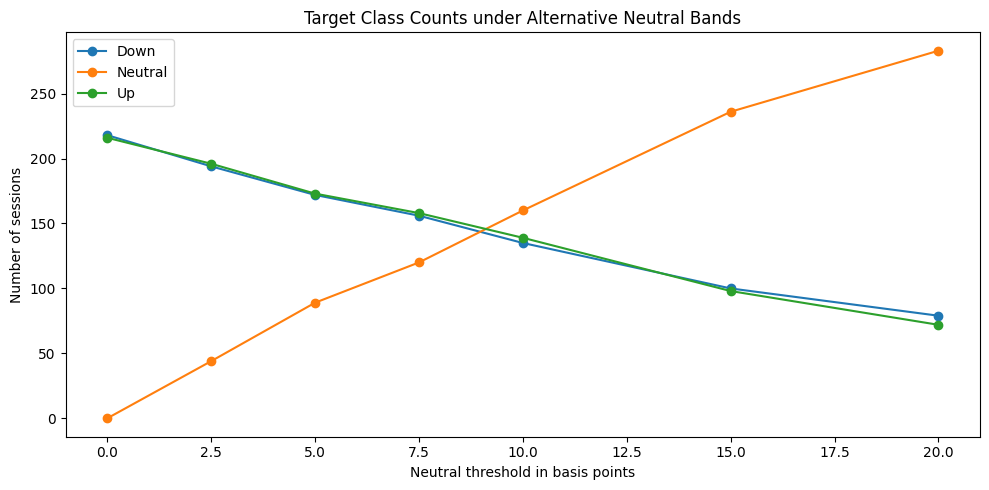

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\cleaning\neutral_threshold_sensitivity.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\cleaning\figures\neutral_threshold_sensitivity.png


In [8]:
thresholds = [0.0, 0.00025, 0.00050, 0.00075, 0.00100, 0.00150, 0.00200]
rows = []
for threshold in thresholds:
    labels = np.select(
        [clean_daily["final_hour_return"] > threshold, clean_daily["final_hour_return"] < -threshold],
        ["Up", "Down"],
        default="Neutral",
    )
    counts = pd.Series(labels).value_counts()
    up = int(counts.get("Up", 0))
    down = int(counts.get("Down", 0))
    neutral = int(counts.get("Neutral", 0))
    directional = up + down
    rows.append(
        {
            "threshold_return": threshold,
            "threshold_basis_points": threshold * 10_000,
            "Down": down,
            "Neutral": neutral,
            "Up": up,
            "directional_sessions": directional,
            "directional_pct": directional / len(clean_daily) * 100,
            "directional_majority_baseline_pct": max(up, down) / directional * 100 if directional else np.nan,
        }
    )

threshold_sensitivity = pd.DataFrame(rows)
display(threshold_sensitivity)

fig, ax = plt.subplots(figsize=(10, 5))
for label in ["Down", "Neutral", "Up"]:
    ax.plot(threshold_sensitivity["threshold_basis_points"], threshold_sensitivity[label], marker="o", label=label)
ax.set_title("Target Class Counts under Alternative Neutral Bands")
ax.set_xlabel("Neutral threshold in basis points")
ax.set_ylabel("Number of sessions")
ax.legend()
figure_path = save_figure(fig, "neutral_threshold_sensitivity.png")
plt.show()

THRESHOLD_PATH = CLEANING_ROOT / "neutral_threshold_sensitivity.csv"
threshold_sensitivity.to_csv(THRESHOLD_PATH, index=False)
print("Saved:", THRESHOLD_PATH)
print("Saved:", figure_path)

## 8. Feature-definition reconciliation

The following table records the definitions most likely to differ from the original project. Freeze these formulas before comparing new and old model results.

In [9]:
feature_definition_review = pd.DataFrame(
    [
        ["final_hour_return", "14:59 SPX close to 15:59 SPX close", "Confirm original timestamp convention", "Retain completed-bar convention"],
        ["ret_open_to_1500", "First regular-session SPX open to 14:59 close", "Confirm original cutoff", "Retain current definition"],
        ["ret_last_15m/30m/60m", "Timestamp-window returns ending at 14:59", "Original may use row offsets or 15-minute candles", "Prefer timestamp windows"],
        ["vix_ret_last_15m/30m/60m", "Backward-aligned VIX returns ending at 14:59", "Original may forward-fill", "Retain backward matching"],
        ["realized_volatility", "Square root of sum of squared one-minute log returns", "Check annualisation/scaling", "Document units and freeze definition"],
        ["spy_volume_accel_60m_vs_avg", "Last-60m volume versus earlier-session average minute volume scaled to 60m", "Likely formula difference", "Confirm or rename"],
        ["spy_dist_from_vwap_pct", "14:59 SPY close versus minute-VWAP weighted cumulative VWAP", "Check original VWAP construction", "Validate on sample dates"],
        ["momentum_accel_60m_vs_prior", "Recent 60m return minus preceding 60m return", "Check whether original used slope or ratio", "Retain only with explicit formula"],
        ["atr_open_to_1500", "Mean one-minute true range from open through 14:59", "Not conventional 14-period ATR", "Rename or reproduce original ATR"],
    ],
    columns=["feature", "current_definition", "comparison_issue", "recommended_action"],
)
display(feature_definition_review)
FEATURE_DEFINITION_PATH = CLEANING_ROOT / "feature_definition_review.csv"
feature_definition_review.to_csv(FEATURE_DEFINITION_PATH, index=False)
print("Saved:", FEATURE_DEFINITION_PATH)

,feature,current_definition,comparison_issue,recommended_action
0,final_hour_return,14:59 SPX close to 15:59 SPX close,Confirm original timestamp convention,Retain completed-bar convention
1,ret_open_to_1500,First regular-session SPX open to 14:59 close,Confirm original cutoff,Retain current definition
2,ret_last_15m/30m/60m,Timestamp-window returns ending at 14:59,Original may use row offsets or 15-minute candles,Prefer timestamp windows
3,vix_ret_last_15m/30m/60m,Backward-aligned VIX returns ending at 14:59,Original may forward-fill,Retain backward matching
4,realized_volatility,Square root of sum of squared one-minute log r...,Check annualisation/scaling,Document units and freeze definition
5,spy_volume_accel_60m_vs_avg,Last-60m volume versus earlier-session average...,Likely formula difference,Confirm or rename
6,spy_dist_from_vwap_pct,14:59 SPY close versus minute-VWAP weighted cu...,Check original VWAP construction,Validate on sample dates
7,momentum_accel_60m_vs_prior,Recent 60m return minus preceding 60m return,Check whether original used slope or ratio,Retain only with explicit formula
8,atr_open_to_1500,Mean one-minute true range from open through 1...,Not conventional 14-period ATR,Rename or reproduce original ATR


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\cleaning\feature_definition_review.csv


## 9. Chronological train/validation/test split

Preprocessing is fitted only after the split. The final test period remains untouched until the complete modelling procedure is fixed.

In [10]:
TRAIN_SHARE = 0.70
VALIDATION_SHARE = 0.15

n = len(clean_daily)
train_end = int(np.floor(n * TRAIN_SHARE))
validation_end = int(np.floor(n * (TRAIN_SHARE + VALIDATION_SHARE)))

clean_daily["data_split"] = np.select(
    [clean_daily.index < train_end, clean_daily.index < validation_end],
    ["Train", "Validation"],
    default="Test",
)

split_summary = clean_daily.groupby("data_split", sort=False).agg(
    sessions=("session_date", "size"),
    first_date=("session_date", "min"),
    last_date=("session_date", "max"),
    up_sessions=("target_up", lambda x: int(x.eq(1).sum())),
    down_sessions=("target_up", lambda x: int(x.eq(0).sum())),
    mean_target=("final_hour_return", "mean"),
    target_volatility=("final_hour_return", "std"),
).reset_index()
order = pd.Categorical(split_summary["data_split"], ["Train", "Validation", "Test"], ordered=True)
split_summary = split_summary.assign(_order=order).sort_values("_order").drop(columns="_order")
display(split_summary)

assert clean_daily.loc[clean_daily["data_split"].eq("Train"), "session_date"].max() < clean_daily.loc[clean_daily["data_split"].eq("Validation"), "session_date"].min()
assert clean_daily.loc[clean_daily["data_split"].eq("Validation"), "session_date"].max() < clean_daily.loc[clean_daily["data_split"].eq("Test"), "session_date"].min()

SPLIT_PATH = DERIVED_ROOT / "daily_underlying_model_dataset_clean_split.parquet"
clean_daily.to_parquet(SPLIT_PATH, index=False)
SPLIT_SUMMARY_PATH = CLEANING_ROOT / "split_summary.csv"
split_summary.to_csv(SPLIT_SUMMARY_PATH, index=False)
print("Saved:", SPLIT_PATH)
print("Saved:", SPLIT_SUMMARY_PATH)

,data_split,sessions,first_date,last_date,up_sessions,down_sessions,mean_target,target_volatility
0,Train,303,2024-07-18,2025-12-03,147,156,-0.000080,0.003307
1,Validation,65,2025-12-04,2026-03-20,29,36,-0.000024,0.002761
2,Test,66,2026-03-23,2026-07-17,40,26,0.000172,0.002354


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data\derived\daily_underlying_model_dataset_clean_split.parquet
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\cleaning\split_summary.csv


## 10. Training-only multicollinearity audit

Highly correlated feature pairs are flagged using training data only. They are not automatically removed because regularised linear and tree-based models handle redundancy differently.

In [11]:
train = clean_daily[clean_daily["data_split"].eq("Train")].copy()
usable_features = [c for c in feature_columns if c not in constant_features]
train_corr = train[usable_features].corr(method="spearman")

HIGH_CORRELATION_THRESHOLD = 0.90
pairs = []
for i, first in enumerate(train_corr.columns):
    for second in train_corr.columns[i + 1:]:
        value = train_corr.loc[first, second]
        if pd.notna(value) and abs(value) >= HIGH_CORRELATION_THRESHOLD:
            pairs.append(
                {
                    "feature_1": first,
                    "feature_2": second,
                    "spearman_correlation": value,
                    "absolute_correlation": abs(value),
                }
            )

high_correlation_pairs = pd.DataFrame(pairs)
if not high_correlation_pairs.empty:
    high_correlation_pairs = high_correlation_pairs.sort_values("absolute_correlation", ascending=False)
display(high_correlation_pairs)

CORRELATION_PATH = CLEANING_ROOT / "high_correlation_pairs_train_only.csv"
high_correlation_pairs.to_csv(CORRELATION_PATH, index=False)
print("Saved:", CORRELATION_PATH)

,feature_1,feature_2,spearman_correlation,absolute_correlation
2,ret_open_to_1500,dist_from_open_pct,1.000000,1.000000
0,spx_at_1500,spy_at_1500,0.999778,0.999778
1,ret_open_to_1500,spy_ret_open_to_1500,0.983945,0.983945
7,spy_ret_open_to_1500,dist_from_open_pct,0.983945,0.983945
6,rv_open_to_1500,atr_open_to_1500,0.965850,0.965850
3,realized_vol_30m,realized_vol_60m,0.961370,0.961370
5,realized_vol_60m,realized_vol_120m,0.957135,0.957135
8,spy_volume_last_30m,spy_volume_last_60m,0.939626,0.939626
9,spy_dist_from_vwap_pct,position_in_day_range,0.916986,0.916986
4,realized_vol_30m,realized_vol_120m,0.910909,0.910909


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\cleaning\high_correlation_pairs_train_only.csv


## 11. Training-only imputation and outlier clipping

The clean split dataset remains the main research artifact. A separate model-ready dataset is created for algorithms requiring finite complete inputs.

Median imputation and 1st/99th percentile clipping are fitted on training data only and then applied unchanged to validation and test rows.

In [12]:
LOWER_QUANTILE = 0.01
UPPER_QUANTILE = 0.99
parameters = []
for feature in usable_features:
    series = pd.to_numeric(train[feature], errors="coerce")
    parameters.append(
        {
            "feature": feature,
            "training_median": series.median(),
            "lower_quantile": LOWER_QUANTILE,
            "lower_value": series.quantile(LOWER_QUANTILE),
            "upper_quantile": UPPER_QUANTILE,
            "upper_value": series.quantile(UPPER_QUANTILE),
            "training_missing": int(series.isna().sum()),
        }
    )

preprocessing_parameters = pd.DataFrame(parameters)
display(preprocessing_parameters)

model_ready = clean_daily.copy()
for row in preprocessing_parameters.itertuples():
    feature = row.feature
    model_ready[feature] = pd.to_numeric(model_ready[feature], errors="coerce")
    model_ready[feature] = model_ready[feature].fillna(row.training_median)
    model_ready[feature] = model_ready[feature].clip(lower=row.lower_value, upper=row.upper_value)

assert model_ready[usable_features].isna().sum().sum() == 0
assert np.isfinite(model_ready[usable_features].to_numpy(dtype=float)).all()

PREPROCESSING_PATH = CLEANING_ROOT / "training_preprocessing_parameters.csv"
MODEL_READY_PATH = DERIVED_ROOT / "daily_underlying_model_dataset_model_ready.parquet"
preprocessing_parameters.to_csv(PREPROCESSING_PATH, index=False)
model_ready.to_parquet(MODEL_READY_PATH, index=False)
print("Saved:", PREPROCESSING_PATH)
print("Saved:", MODEL_READY_PATH)

,feature,training_median,lower_quantile,lower_value,upper_quantile,upper_value,training_missing
0,spx_at_1500,"5,940.780000",0.010000,"5,105.811600",0.990000,"6,850.715600",0
1,vix_level_1500,17.670000,0.010000,13.661000,0.990000,42.092600,0
2,spy_at_1500,592.070000,0.010000,508.909098,0.990000,683.133400,0
3,ret_open_to_1500,0.000091,0.010000,-0.022116,0.990000,0.017979,0
4,ret_last_15m,0.000012,0.010000,-0.005644,0.990000,0.002386,0
5,ret_last_30m,0.000125,0.010000,-0.006219,0.990000,0.005121,0
6,ret_last_60m,0.000033,0.010000,-0.009757,0.990000,0.007469,0
7,vix_ret_last_15m,-0.002009,0.010000,-0.028483,0.990000,0.046959,0
8,vix_ret_last_30m,-0.003748,0.010000,-0.038821,0.990000,0.054987,0
9,vix_ret_last_60m,-0.006549,0.010000,-0.055865,0.990000,0.074905,0


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\cleaning\training_preprocessing_parameters.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data\derived\daily_underlying_model_dataset_model_ready.parquet


## 12. Look-ahead and target consistency checks

In [13]:
if "feature_cutoff_timestamp_utc" in clean_daily.columns:
    cutoff_et = clean_daily["feature_cutoff_timestamp_utc"].dt.tz_convert("America/New_York")
    cutoff_distribution = cutoff_et.dt.strftime("%H:%M:%S").value_counts().rename_axis("cutoff_time_et").reset_index(name="sessions")
    display(cutoff_distribution)
    assert set(cutoff_distribution["cutoff_time_et"]) == {"14:59:00"}

reconstructed_target = clean_daily["spx_at_close"] / clean_daily["spx_at_1500"] - 1
assert np.isclose(clean_daily["final_hour_return"], reconstructed_target).all()
assert not clean_daily.duplicated(["session_date"]).any()
print("Look-ahead, target formula and duplicate checks passed.")

,cutoff_time_et,sessions
0,14:59:00,434


Look-ahead, target formula and duplicate checks passed.


## 13. Cleaning manifest and output summary

In [14]:
manifest = {
    "source_daily_rows": int(cleaning_counts["source_daily_rows"]),
    "strict_session_rows": int(cleaning_counts["strict_session_rows"]),
    "binary_target_rows": int(cleaning_counts["binary_target_rows"]),
    "removed_exact_zero_rows": int(cleaning_counts["removed_exact_zero_rows"]),
    "required_session_minutes": 390,
    "feature_cutoff_et": "14:59:00",
    "target_end_et": "15:59:00",
    "critical_missingness_window": "13:00:00-14:59:00 ET",
    "primary_target": "binary sign of final_hour_return",
    "train_share": TRAIN_SHARE,
    "validation_share": VALIDATION_SHARE,
    "test_share": 1 - TRAIN_SHARE - VALIDATION_SHARE,
    "imputation": "training median",
    "outlier_treatment": "training 1st/99th percentile clipping",
    "high_correlation_threshold": HIGH_CORRELATION_THRESHOLD,
}
MANIFEST_PATH = CLEANING_ROOT / "cleaning_manifest.json"
with MANIFEST_PATH.open("w", encoding="utf-8") as handle:
    json.dump(manifest, handle, indent=2)

output_summary = pd.DataFrame(
    {
        "artifact": [
            "Eligibility review", "Clean binary dataset", "Clean split dataset",
            "Model-ready dataset", "Feature audit", "Threshold sensitivity",
            "Feature-definition review", "Training preprocessing parameters",
            "Training correlation pairs", "Cleaning manifest",
        ],
        "path": [
            str(ELIGIBILITY_PATH), str(CLEAN_DATASET_PATH), str(SPLIT_PATH),
            str(MODEL_READY_PATH), str(FEATURE_AUDIT_PATH), str(THRESHOLD_PATH),
            str(FEATURE_DEFINITION_PATH), str(PREPROCESSING_PATH),
            str(CORRELATION_PATH), str(MANIFEST_PATH),
        ],
    }
)
display(output_summary)
print(json.dumps(manifest, indent=2))

,artifact,path
0,Eligibility review,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
1,Clean binary dataset,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
2,Clean split dataset,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
3,Model-ready dataset,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
4,Feature audit,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
5,Threshold sensitivity,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
6,Feature-definition review,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
7,Training preprocessing parameters,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
8,Training correlation pairs,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
9,Cleaning manifest,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...


{
  "source_daily_rows": 496,
  "strict_session_rows": 434,
  "binary_target_rows": 434,
  "removed_exact_zero_rows": 0,
  "required_session_minutes": 390,
  "feature_cutoff_et": "14:59:00",
  "target_end_et": "15:59:00",
  "critical_missingness_window": "13:00:00-14:59:00 ET",
  "primary_target": "binary sign of final_hour_return",
  "train_share": 0.7,
  "validation_share": 0.15,
  "test_share": 0.15000000000000005,
  "imputation": "training median",
  "outlier_treatment": "training 1st/99th percentile clipping",
  "high_correlation_threshold": 0.9
}


## 14. Modelling handoff

Use `daily_underlying_model_dataset_clean_split.parquet` as the primary modelling source when preprocessing is placed inside a scikit-learn pipeline or walk-forward validation loop.

Use `daily_underlying_model_dataset_model_ready.parquet` only for initial benchmarks or algorithms that require a complete finite matrix.

The next notebook should compare majority-class, persistence, momentum and mean-reversion baselines with regularised logistic regression and tree-based models using expanding-window validation. The test period must remain untouched.